# Auto-Encoders on MNIST
## Task 1: Fully Connected Auto-Encoder
## Task 2: Convolutional Auto-Encoder
## Task 3: t-SNE Visualization
## Task 4: Side-by-side Reconstruction Comparison

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import struct
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE

---
## Task 1: Fully Connected Auto-Encoder

Three separate classes:
- **`FCEncoder`** — encoder only: `Linear(784→256) → ReLU → Linear(256→64) → ReLU`
- **`FCDecoder`** — decoder only: `Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`
- **`FCAutoEncoder`** — wires `FCEncoder` + `FCDecoder` together

```
FCAutoEncoder
├── self.encoder  →  FCEncoder   (input → hidden → latent)
└── self.decoder  →  FCDecoder   (latent → hidden → output)
```

In [2]:
class FCEncoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=64):
        super(FCEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # hidden layer
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),  # bottleneck
            nn.ReLU()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten image to vector
        return self.encoder(x)


class FCDecoder(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=256, output_dim=784):
        super(FCDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),  # hidden layer
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),  # reconstruct
            nn.Sigmoid()                         # output in [0, 1]
        )

    def forward(self, z):
        return self.decoder(z)


# Combines FCEncoder + FCDecoder into the full auto-encoder.
class FCAutoEncoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=64):
        super(FCAutoEncoder, self).__init__()
        self.encoder = FCEncoder(input_dim, hidden_dim, latent_dim)
        self.decoder = FCDecoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        x_hat = x_hat.view(x.size())  # reshape back to original image shape
        return x_hat


fc_autoencoder = FCAutoEncoder(input_dim=784, hidden_dim=256, latent_dim=64)
print('TASK 1: Fully Connected Auto-Encoder')
print(fc_autoencoder)

TASK 1: Fully Connected Auto-Encoder
FCAutoEncoder(
  (encoder): FCEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=64, bias=True)
      (3): ReLU()
    )
  )
  (decoder): FCDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)


---
## Task 2: Convolutional Auto-Encoder

- **`ConvEncoder`** — replaces `FCEncoder` with conv layers: `Conv2d(1→16) → ReLU → Conv2d(16→32) → ReLU → flatten → Linear(1568→64)`
- **`FCDecoder`** — reused from Task 1 (unchanged)
- **`ConvAutoEncoder`** — wires `ConvEncoder` + `FCDecoder` together

**`ConvEncoder`** — convolutional encoder that replaces the fully connected encoder from Task 1.

In [3]:
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(ConvEncoder, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        self.fc = nn.Linear(32 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flatten
        return torch.relu(self.fc(x))

In [4]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=256, output_dim=784):
        super(ConvAutoEncoder, self).__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = FCDecoder(latent_dim, hidden_dim, output_dim)  # same as Task 1

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        x_hat = x_hat.view(x.size())  # reshape back to (B, 1, 28, 28)
        return x_hat


conv_autoencoder = ConvAutoEncoder(latent_dim=64, hidden_dim=256, output_dim=784)
print('TASK 2: Convolutional Auto-Encoder')
print(conv_autoencoder)

TASK 2: Convolutional Auto-Encoder
ConvAutoEncoder(
  (encoder): ConvEncoder(
    (conv_layers): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (fc): Linear(in_features=1568, out_features=64, bias=True)
  )
  (decoder): FCDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)


**`ConvAutoEncoder`** combines the two parts:
- **Encoder** — convolutional layers (replaces the FC encoder from Task 1)
- **Decoder** — same fully connected decoder as Task 1

---
## Data Loading
Load MNIST train and test data directly from local IDX files.

In [5]:
def load_idx_images(path):
    with open(path, 'rb') as f:
        _, n, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, 1, rows, cols).astype(np.float32) / 255.0  # normalize to [0, 1]


def load_idx_labels(path):
    with open(path, 'rb') as f:
        _, n = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n)


def get_dataloader(batch_size=128):
    images = load_idx_images('MNIST/train-images.idx3-ubyte')
    images = torch.from_numpy(images)
    dataset = TensorDataset(images)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


def get_test_data():
    images = load_idx_images('MNIST/t10k-images.idx3-ubyte')
    labels = load_idx_labels('MNIST/t10k-labels.idx1-ubyte')
    return torch.from_numpy(images), labels


dataloader = get_dataloader(batch_size=128)
print(f'Train: {len(dataloader.dataset)} images')

test_images, test_labels = get_test_data()
print(f'Test:  {len(test_images)} images, {len(test_labels)} labels')

Train: 60000 images
Test:  10000 images, 10000 labels


---
## Training Function
Shared for both tasks. Uses **Adam** optimizer and **MSE** loss.  
Returns `loss_history` (list of avg MSE per epoch) so we can plot it.

In [6]:
def train(model, dataloader, num_epochs=10, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()  # MSE between x and x_hat
    loss_history = []

    for epoch in range(num_epochs):
        total_loss = 0
        for (images,) in dataloader:
            images = images.to(device)
            x_hat = model(images)
            loss = criterion(x_hat, images)  # MSE(x, x_hat)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}]  MSE Loss: {avg_loss:.6f}')

    return loss_history

---
## Loss Chart
Plots MSE loss per epoch — a steadily decreasing curve means the model is learning.

In [7]:
def plot_loss(loss_history, title='Training Loss'):
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

---
## Reconstruction Visualization
Shows **n original images** (top row) vs **reconstructions** (bottom row) after training.

In [8]:
def visualize(model, dataloader, title='Auto-Encoder', n=8):
    device = next(model.parameters()).device
    images = next(iter(dataloader))[0][:n].to(device)

    model.eval()
    with torch.no_grad():
        reconstructed = model(images)
    model.train()

    images = images.cpu().squeeze(1).numpy()
    reconstructed = reconstructed.cpu().squeeze(1).numpy()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(images[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_title('Original', loc='left', fontsize=10)
    axes[1, 0].set_title('Reconstructed', loc='left', fontsize=10)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

---
## Weight Initialization — He / Kaiming (best for ReLU)

**He init = Kaiming init** — scales variance by `2 / fan_in` to compensate for ReLU zeroing out half the neurons.

In [9]:
def init_weights(m):
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')  # He init for ReLU hidden layers
        nn.init.zeros_(m.bias)

---
## Task 3: t-SNE Visualization

t-SNE maps high-dimensional data into 2D so we can see how well the encoder has **separated the digit classes** in latent space.

We compare **3 plots** for each autoencoder:
| Plot | Input to t-SNE | What it shows |
|---|---|---|
| Raw images | Flattened 784-dim pixels | Baseline — no learned features |
| Task 1 embeddings | 64-dim FC encoder output | What the FC encoder learned |
| Task 2 embeddings | 64-dim Conv encoder output | What the Conv encoder learned |

Well-separated clusters = the encoder has learned meaningful class structure.

In [10]:
def get_embeddings(encoder, images, batch_size=256):
    device = next(encoder.parameters()).device
    encoder.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i + batch_size].to(device)
            z = encoder(batch)
            embeddings.append(z.cpu().numpy())
    encoder.train()
    return np.concatenate(embeddings, axis=0)  # (N, latent_dim)


def plot_tsne(embeddings, labels, title='t-SNE'):
    print(f'Running t-SNE on {embeddings.shape}...')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    coords = tsne.fit_transform(embeddings)   # (N, 2)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                          c=labels, cmap='tab10', s=5, alpha=0.6)
    plt.colorbar(scatter, ticks=range(10), label='Digit class')
    plt.title(title)
    plt.xlabel('t-SNE dim 1')
    plt.ylabel('t-SNE dim 2')
    plt.tight_layout()
    plt.show()

---
## Run — Task 1: Fully Connected Auto-Encoder

FCAutoEncoder(
  (encoder): FCEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=784, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=64, bias=True)
      (3): ReLU()
    )
  )
  (decoder): FCDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)
Epoch [1/10]  MSE Loss: 0.030090
Epoch [2/10]  MSE Loss: 0.010984
Epoch [3/10]  MSE Loss: 0.008878
Epoch [4/10]  MSE Loss: 0.007950
Epoch [5/10]  MSE Loss: 0.007392
Epoch [6/10]  MSE Loss: 0.007014
Epoch [7/10]  MSE Loss: 0.006723
Epoch [8/10]  MSE Loss: 0.006465
Epoch [9/10]  MSE Loss: 0.006186
Epoch [10/10]  MSE Loss: 0.005969


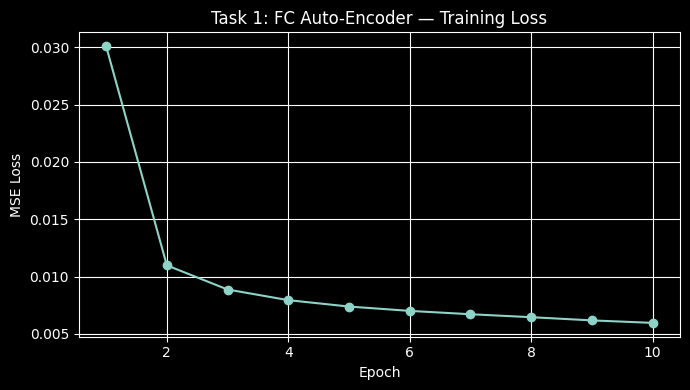

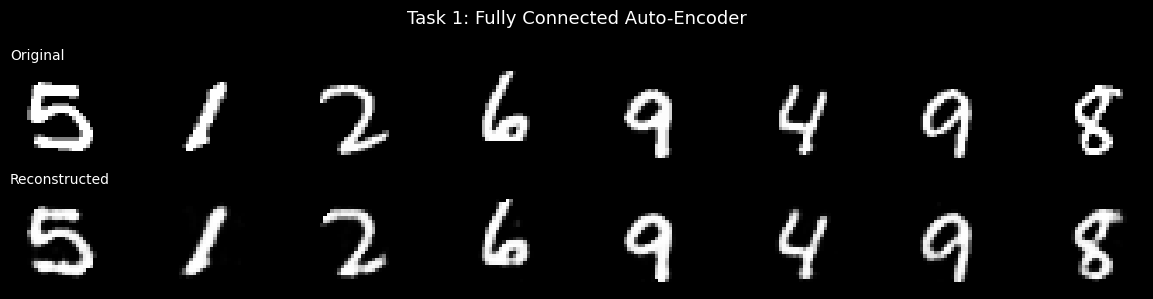

In [11]:
fc_autoencoder = FCAutoEncoder(input_dim=784, hidden_dim=256, latent_dim=64)
fc_autoencoder.apply(init_weights)  # apply He initialization
print(fc_autoencoder)

loss1 = train(fc_autoencoder, dataloader, num_epochs=10)
plot_loss(loss1, title='Task 1: FC Auto-Encoder — Training Loss')
visualize(fc_autoencoder, dataloader, title='Task 1: Fully Connected Auto-Encoder')

## Run — Task 2: Convolutional Auto-Encoder

ConvAutoEncoder(
  (encoder): ConvEncoder(
    (conv_layers): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (fc): Linear(in_features=1568, out_features=64, bias=True)
  )
  (decoder): FCDecoder(
    (decoder): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)
Epoch [1/10]  MSE Loss: 0.036410
Epoch [2/10]  MSE Loss: 0.017741
Epoch [3/10]  MSE Loss: 0.015883
Epoch [4/10]  MSE Loss: 0.014685
Epoch [5/10]  MSE Loss: 0.014051
Epoch [6/10]  MSE Loss: 0.013576
Epoch [7/10]  MSE Loss: 0.013134
Epoch [8/10]  MSE Loss: 0.012785
Epoch [9/10]  MSE Loss: 0.012285
Epoch [10/10]  MSE Loss: 0.011752


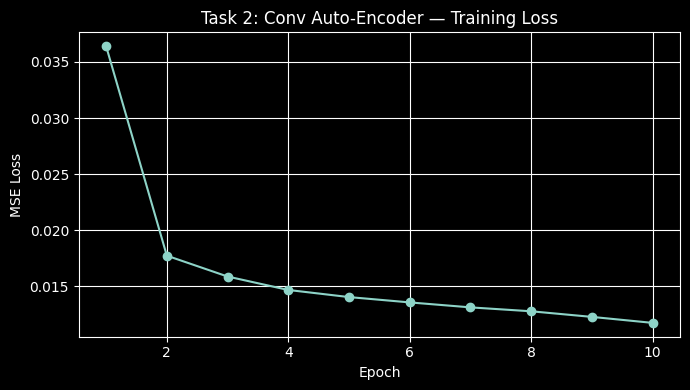

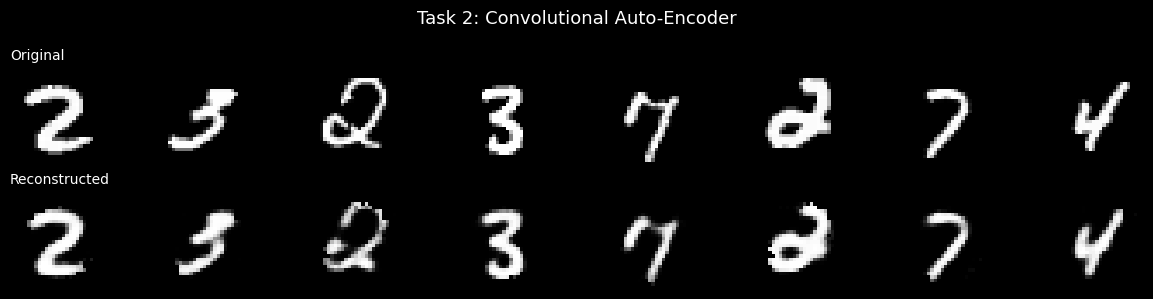

In [12]:
conv_autoencoder = ConvAutoEncoder(latent_dim=64, hidden_dim=256, output_dim=784)
conv_autoencoder.apply(init_weights)  # apply He initialization
print(conv_autoencoder)

loss2 = train(conv_autoencoder, dataloader, num_epochs=10)
plot_loss(loss2, title='Task 2: Conv Auto-Encoder — Training Loss')
visualize(conv_autoencoder, dataloader, title='Task 2: Convolutional Auto-Encoder')

---
## Run — Task 3: t-SNE

Running t-SNE on (10000, 784)...


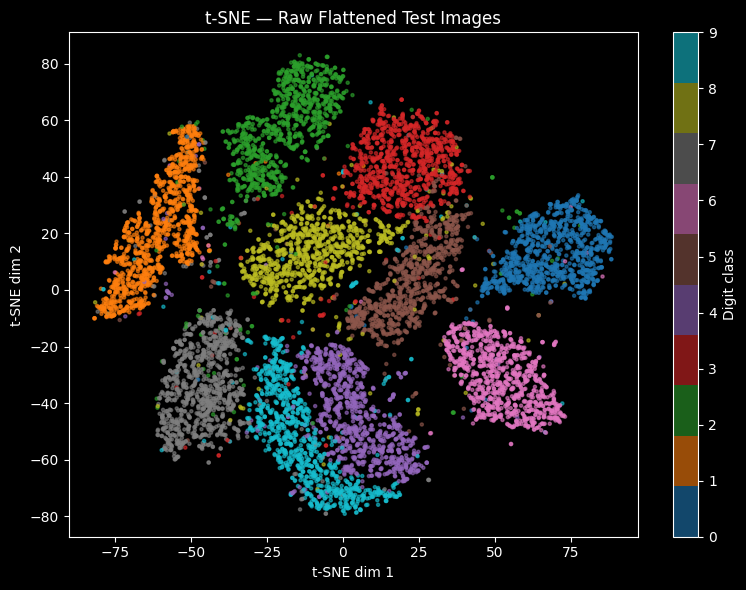

In [13]:
# --- Baseline: raw flattened test images (no encoder) ---
flat = test_images.squeeze(1).view(len(test_images), -1).numpy()  # (10000, 784)
plot_tsne(flat, test_labels, title='t-SNE — Raw Flattened Test Images')

Running t-SNE on (10000, 64)...


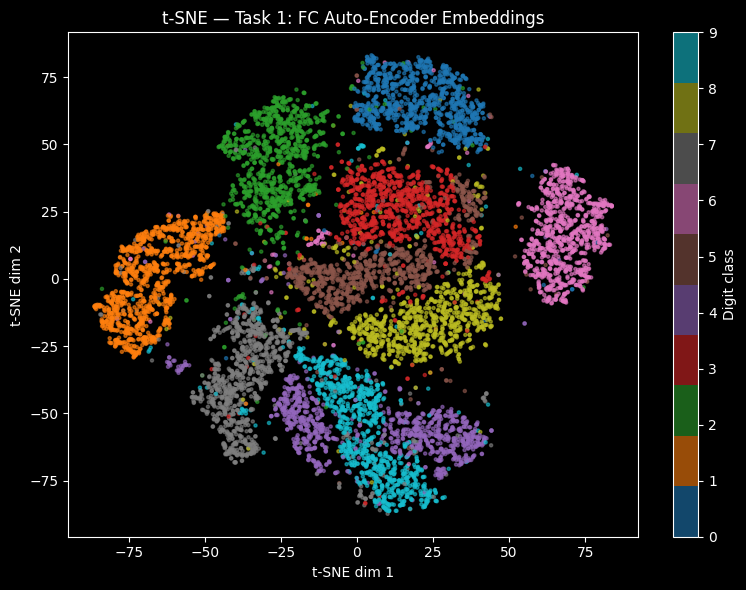

In [14]:
# --- Task 1: FC encoder embeddings ---
emb1 = get_embeddings(fc_autoencoder.encoder, test_images)   # (10000, 64)
plot_tsne(emb1, test_labels, title='t-SNE — Task 1: FC Auto-Encoder Embeddings')

Running t-SNE on (10000, 64)...


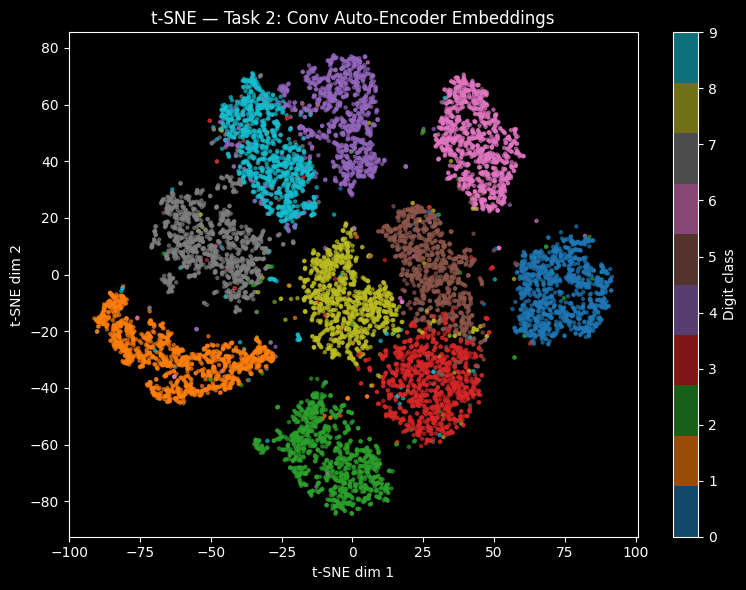

In [15]:
# --- Task 2: Conv encoder embeddings ---
emb2 = get_embeddings(conv_autoencoder.encoder, test_images)  # (10000, 64)
plot_tsne(emb2, test_labels, title='t-SNE — Task 2: Conv Auto-Encoder Embeddings')

In [23]:
def show_reconstructions(fc_model, conv_model, test_images, test_labels, n_classes=3):
    device = next(fc_model.parameters()).device

    # randomly pick n_classes distinct classes
    chosen_classes = np.random.choice(10, size=n_classes, replace=False)

    selected_images = []
    selected_labels = []
    for cls in chosen_classes:
        idx = np.where(test_labels == cls)[0]   # all indices for this class
        pick = np.random.choice(idx)             # pick one randomly
        selected_images.append(test_images[pick])
        selected_labels.append(cls)

    imgs = torch.stack(selected_images).to(device)  # (n_classes, 1, 28, 28)

    fc_model.eval()
    conv_model.eval()
    with torch.no_grad():
        recon_fc   = fc_model(imgs).cpu().squeeze(1).numpy()
        recon_conv = conv_model(imgs).cpu().squeeze(1).numpy()
    fc_model.train()
    conv_model.train()

    originals = imgs.cpu().squeeze(1).numpy()

    fig, axes = plt.subplots(n_classes, 3, figsize=(7, n_classes * 2.5))
    col_titles = ['Original', 'Task 1 — FC Reconstruction', 'Task 2 — Conv Reconstruction']

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10)

    for row in range(n_classes):
        axes[row, 0].imshow(originals[row],  cmap='gray')
        axes[row, 1].imshow(recon_fc[row],   cmap='gray')
        axes[row, 2].imshow(recon_conv[row], cmap='gray')
        axes[row, 0].set_ylabel(f'Class {selected_labels[row]}', fontsize=10)
        for col in range(3):
            axes[row, col].axis('off')

    fig.suptitle('Task 4: Original vs Reconstructions (3 random classes)', fontsize=12)
    plt.tight_layout()
    plt.show()

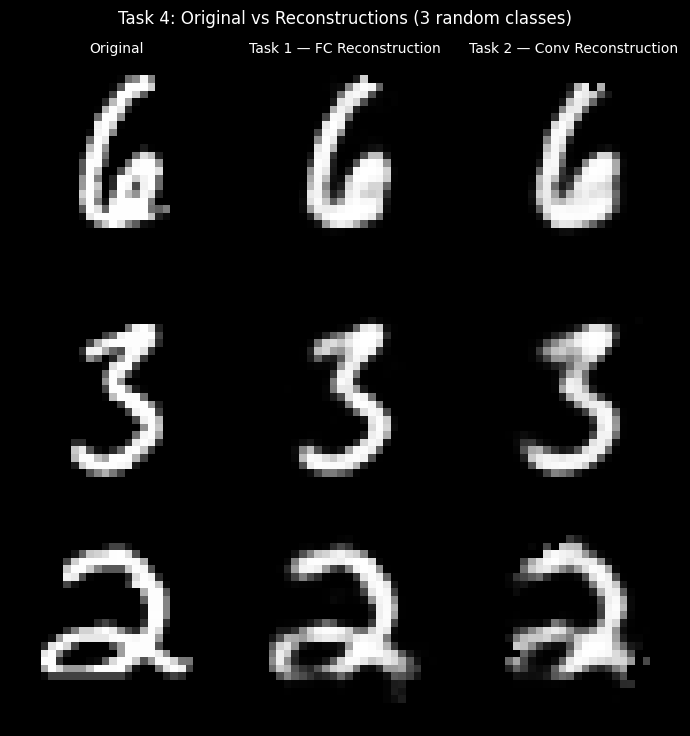

tensor(0.0057)


In [24]:
show_reconstructions(fc_autoencoder, conv_autoencoder, test_images, test_labels, n_classes=3)